<a href="https://colab.research.google.com/github/cpython-projects/python_da_17_03_26/blob/main/lesson_18_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Легенда

**[Students Performance in Exams](https://github.com/cpython-projects/python_da_06_11_25/blob/main/StudentsPerformance.csv)**

Датасет містить інформацію про результати учнів та деякі соціальні характеристики, які можуть впливати на успішність.

## Опис змінних

* **gender** — стать учня
* **race/ethnicity** — етнічна група учня
* **parental level of education** — рівень освіти батьків
* **lunch** — тип харчування в школі
* **test preparation course** — чи проходив учень підготовчий курс перед іспитом
* **math score** — бал за іспит з математики
* **reading score** — бал за іспит з читання
* **writing score** — бал за іспит з письма

In [2]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('https://raw.githubusercontent.com/cpython-projects/python_da_06_11_25/refs/heads/main/StudentsPerformance.csv')
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


# Task 1  

> З якими результатами з математики учні стикаються найчастіше:
> чи більше учнів отримують середні бали, чи результати зосереджені біля мінімуму або максимуму?

In [3]:
df.columns.to_list()

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

In [8]:
fig = px.histogram(
    df,
    x='math score',
    nbins=50,
    title='Розподіл балів з математики'
)

fig.update_layout(
   xaxis_title='Бали з математики',
   yaxis_title='Кількість учнів'
)

fig.show()

In [9]:
df['math score'].mean(), df['math score'].median()

(np.float64(66.089), 66.0)

# Task 2  

> Порівняти середній бал з читання для учнів, які проходили підготовчий курс перед іспитом, і тих, хто його не проходив.
> Яка група виглядає успішнішою?

In [10]:
df_reading_groups = df.groupby('test preparation course')['reading score'].mean().reset_index()
df_reading_groups

,test preparation course,reading score
0,completed,73.893855
1,none,66.534268


In [11]:
px.bar(
    df_reading_groups,
    x='test preparation course',
    y='reading score'
).show()

# Task 3  

> Як відрізняється розподіл балів з письма між учнями з різним рівнем освіти батьків?
> У яких групах результати більш стабільні, а де — сильніше коливаються?

In [12]:
px.box(
    df,
    x='parental level of education',
    y='writing score'
).show()

<Axes: >

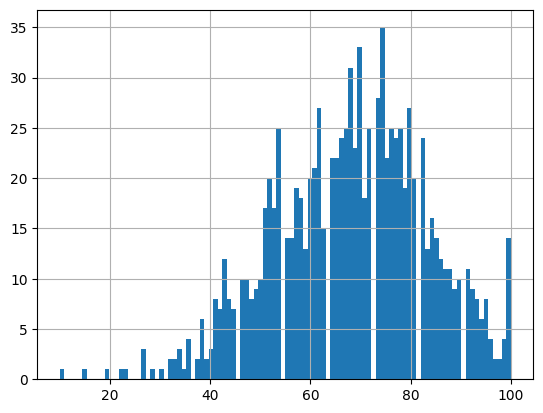

In [13]:
df['writing score'].hist(bins=100)

In [16]:
df.groupby(
  'parental level of education'
)['writing score'].agg(['mean', 'std'])

,mean,std
parental level of education,,
associate's degree,69.896396,14.311122
bachelor's degree,73.381356,14.728262
high school,62.448980,14.085907
master's degree,75.677966,13.730711
some college,68.840708,15.012331
some high school,64.888268,15.736197


In [15]:
df['writing score'].mean()

np.float64(68.054)

# Task 4  

> Як виглядає розташування учнів на площині
> «бал з читання — бал з письма»?
> Чи є учні з нетиповими поєднаннями результатів?

In [21]:
px.scatter(
    df,
    x='reading score',
    y='writing score',
    color='gender'
).show()